In [ ]:
!pip install librosa==0.10.1 soundfile==0.12.1 --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.5 MB/s eta 0:00:00


In [ ]:
!pip install transformers==4.41.0 --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 25.0 MB/s eta 0:00:00


In [ ]:
!pip install pandas==2.2.2 scikit-learn --quiet
!pip install tqdm --quiet

## Section 1b — Imports & Configuration

In [ ]:
#  Standard library
import os
import warnings
warnings.filterwarnings('ignore')

#  Numerical / data
import numpy as np
import pandas as pd
from tqdm import tqdm

#  Audio processing
import librosa

# ── Machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight

# ── TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences

#  HuggingFace Transformers (BERT)
from transformers import BertTokenizer, TFBertModel

#  Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#  Emotion label map (MELD 7 classes)
EMOTIONS    = ['neutral', 'surprise', 'fear', 'sadness', 'joy', 'disgust', 'anger']
NUM_CLASSES = len(EMOTIONS)

#  Hyperparameters (change these to experiment)
SAMPLE_RATE   = 16000  # resample all audio to 16 kHz
N_MFCC        = 40     # number of MFCC coefficients per frame
MAX_AUDIO_LEN = 300    # pad/truncate audio sequences to this many frames
MAX_TEXT_LEN  = 64     # max tokens per utterance for BERT
LSTM_UNITS    = 128    # hidden units in each LSTM encoder
BATCH_SIZE    = 32     # utterances per gradient update
EPOCHS        = 20     # full passes through the training data
LEARNING_RATE = 1e-4   # optimizer step size



In [ ]:
# Check system specs
import subprocess

# Check GPU
print("=== GPU INFO ===")
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        print(result.stdout)
    else:
        print("No NVIDIA GPU detected on this machine.")
except FileNotFoundError:
    print("nvidia-smi not found — no NVIDIA GPU on this machine.")

# Check RAM
print("\n=== RAM INFO ===")
with open('/proc/meminfo') as f:
    for line in f:
        if 'MemTotal' in line or 'MemAvailable' in line:
            print(line.strip())

# Check CPU
print("\n=== CPU INFO ===")
result = subprocess.run(['lscpu'], capture_output=True, text=True)
lines = [l for l in result.stdout.split('\n') if any(k in l for k in ['Model name', 'CPU(s):', 'Thread'])]
for l in lines:
    print(l)

# Check disk space
print("\n=== DISK SPACE ===")
result = subprocess.run(['df', '-h', '/'], capture_output=True, text=True)
print(result.stdout)

=== GPU INFO ===
Mon May  4 18:06:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+------------------------------

In [ ]:
# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU available: {gpus[0].name}")
else:
    print("⚠  No GPU detected.")
    print("   Go to Runtime → Change runtime type → T4 GPU → Save")
    print("   Then re-run Section 1a and 1b from the top.")

print(f"✓ TensorFlow version : {tf.__version__}")
print(f"✓ Pandas version     : {pd.__version__}")
print(f"✓ All imports successful — ready for Section 2.")


✓ GPU available: /physical_device:GPU:0
✓ TensorFlow version : 2.20.0
✓ Pandas version     : 2.2.2
✓ All imports successful — ready for Section 2.


### Section 2a — Mount Google Drive

In [ ]:
from google.colab import drive

# Mount Google Drive at /content/drive
drive.mount('/content/drive')

# Create a project folder on your Drive to store all project files
PROJECT_DIR = '/content/drive/MyDrive/LING5412_MELD'
os.makedirs(PROJECT_DIR, exist_ok=True)

# Sub-folders for data and saved features
DATA_DIR     = os.path.join(PROJECT_DIR, 'data')
FEATURES_DIR = os.path.join(PROJECT_DIR, 'features')
MODELS_DIR   = os.path.join(PROJECT_DIR, 'models')

os.makedirs(DATA_DIR,     exist_ok=True)
os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,   exist_ok=True)

print(f'✓ Google Drive mounted.')
print(f'✓ Project folder  : {PROJECT_DIR}')
print(f'✓ Data folder     : {DATA_DIR}')
print(f'✓ Features folder : {FEATURES_DIR}')
print(f'✓ Models folder   : {MODELS_DIR}')

Mounted at /content/drive
✓ Google Drive mounted.
✓ Project folder  : /content/drive/MyDrive/LING5412_MELD
✓ Data folder     : /content/drive/MyDrive/LING5412_MELD/data
✓ Features folder : /content/drive/MyDrive/LING5412_MELD/features
✓ Models folder   : /content/drive/MyDrive/LING5412_MELD/models


### Section 2b — Download MELD Dataset


In [ ]:
import zipfile

# ── Check if data already downloaded (skip if re-running after disconnect) ──
csv_path = os.path.join(DATA_DIR, 'train_sent_emo.csv')

if os.path.exists(csv_path):
    print('✓ MELD data already downloaded — skipping download.')
else:
    print('Downloading MELD dataset from HuggingFace...')
    print('This will take 3–5 minutes (~2.5 GB). Keep this tab open.')

    # Download the MELD zip file
    !wget -q --show-progress \
        'https://huggingface.co/datasets/declare-lab/MELD/resolve/main/MELD.Raw.tar.gz' \
        -O /content/MELD.tar.gz

    print('Extracting files...')
    !tar -xzf /content/MELD.tar.gz -C /content/

    # Copy CSVs and audio to our project Drive folder
    !cp /content/MELD_Raw/train_sent_emo.csv {DATA_DIR}/
    !cp /content/MELD_Raw/dev_sent_emo.csv   {DATA_DIR}/
    !cp /content/MELD_Raw/test_sent_emo.csv  {DATA_DIR}/
    !cp -r /content/MELD_Raw/train_splits    {DATA_DIR}/
    !cp -r /content/MELD_Raw/dev_splits      {DATA_DIR}/
    !cp -r /content/MELD_Raw/test_splits     {DATA_DIR}/

    print('✓ Download and extraction complete.')

# Confirm all key files exist
files_to_check = [
    os.path.join(DATA_DIR, 'train_sent_emo.csv'),
    os.path.join(DATA_DIR, 'dev_sent_emo.csv'),
    os.path.join(DATA_DIR, 'test_sent_emo.csv'),
]

for f in files_to_check:
    status = '✓' if os.path.exists(f) else '✗ MISSING'
    print(f'{status}  {os.path.basename(f)}')

This will take 3–5 minutes (~2.5 GB). Keep this tab open.
/content/MELD.tar.g  31%[=====>              ]   3.16G  56.8MB/s    eta 2m 16s ^C
Extracting files...

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
cp: cannot stat '/content/MELD_Raw/train_sent_emo.csv': No such file or directory
cp: cannot stat '/content/MELD_Raw/dev_sent_emo.csv': No such file or directory
cp: cannot stat '/content/MELD_Raw/test_sent_emo.csv': No such file or directory
cp: cannot stat '/content/MELD_Raw/train_splits': No such file or directory
cp: cannot stat '/content/MELD_Raw/dev_splits': No such file or directory
cp: cannot stat '/content/MELD_Raw/test_splits': No such file or directory
✓ Download and extraction complete.
✗ MISSING  train_sent_emo.csv
✗ MISSING  dev_sent_emo.csv
✗ MISSING  test_sent_emo.csv


### Section 2c — Load CSVs into Pandas

In [ ]:
# Check what actually exists in your data folder
import os

print("Contents of DATA_DIR:")
if os.path.exists(DATA_DIR):
    items = os.listdir(DATA_DIR)
    if items:
        for item in items:
            print(f"  {item}")
    else:
        print("  (empty folder)")
else:
    print("  DATA_DIR does not exist at all")

print(f"\nDATA_DIR path: {DATA_DIR}")

Contents of DATA_DIR:
  (empty folder)

DATA_DIR path: /content/drive/MyDrive/LING5412_MELD/data


In [ ]:
import subprocess

# Download just the CSV files first (small, fast)
print('Downloading CSV files...')

csv_files = [
    'train_sent_emo.csv',
    'dev_sent_emo.csv',
    'test_sent_emo.csv'
]

base_url = 'https://huggingface.co/datasets/declare-lab/MELD/resolve/main/MELD.Raw'

for fname in csv_files:
    out_path = os.path.join(DATA_DIR, fname)
    if os.path.exists(out_path):
        print(f'✓ {fname} already exists — skipping.')
    else:
        print(f'  Downloading {fname}...')
        !wget -q "{base_url}/{fname}" -O "{out_path}"
        if os.path.exists(out_path):
            size = os.path.getsize(out_path)
            print(f'✓ {fname} ({size/1024:.0f} KB)')
        else:
            print(f'✗ FAILED: {fname}')

print('\nChecking files:')
for fname in csv_files:
    path = os.path.join(DATA_DIR, fname)
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f'  {status}  {fname}')

✓ train_sent_emo.csv (0 KB)
✓ dev_sent_emo.csv (0 KB)
✓ test_sent_emo.csv (0 KB)

Checking files:
  ✓  train_sent_emo.csv
  ✓  dev_sent_emo.csv
  ✓  test_sent_emo.csv


In [ ]:
# Download CSVs directly from GitHub (correct source)
import urllib.request

csv_files = {
    'train_sent_emo.csv': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/train_sent_emo.csv',
    'dev_sent_emo.csv':   'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/dev_sent_emo.csv',
    'test_sent_emo.csv':  'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/test_sent_emo.csv',
}

for fname, url in csv_files.items():
    out_path = os.path.join(DATA_DIR, fname)
    print(f'Downloading {fname}...')
    urllib.request.urlretrieve(url, out_path)
    size_kb = os.path.getsize(out_path) / 1024
    print(f'  ✓ {fname} ({size_kb:.0f} KB)')

print('\nAll CSVs downloaded.')


  ✓ train_sent_emo.csv (1093 KB)
  ✓ dev_sent_emo.csv (119 KB)
  ✓ test_sent_emo.csv (288 KB)

All CSVs downloaded.


In [ ]:
# Load the three splits
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_sent_emo.csv'))
dev_df   = pd.read_csv(os.path.join(DATA_DIR, 'dev_sent_emo.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_sent_emo.csv'))

# Build audio file path column for each row
def make_audio_path(row, split):
    fname  = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
    folder = os.path.join(DATA_DIR, f'{split}_splits')
    return os.path.join(folder, fname)

train_df['audio_path'] = train_df.apply(lambda r: make_audio_path(r, 'train'), axis=1)
dev_df['audio_path']   = dev_df.apply(lambda r: make_audio_path(r, 'dev'),   axis=1)
test_df['audio_path']  = test_df.apply(lambda r: make_audio_path(r, 'test'),  axis=1)

# Encode emotion labels to integers
label_encoder = LabelEncoder()
label_encoder.fit(EMOTIONS)

train_df['label'] = label_encoder.transform(train_df['Emotion'])
dev_df['label']   = label_encoder.transform(dev_df['Emotion'])
test_df['label']  = label_encoder.transform(test_df['Emotion'])

# Print summary
print('Dataset loaded successfully.')
print(f'  Train : {len(train_df):,} utterances')
print(f'  Dev   : {len(dev_df):,} utterances')
print(f'  Test  : {len(test_df):,} utterances')
print(f'  Total : {len(train_df)+len(dev_df)+len(test_df):,} utterances')
print()
print('Sample row:')
print(train_df[['Utterance','Emotion','label','Speaker']].iloc[0])

Dataset loaded successfully.
  Train : 9,989 utterances
  Dev   : 1,109 utterances
  Test  : 2,610 utterances
  Total : 13,708 utterances

Sample row:
Utterance    also I was the point person on my company’s tr...
Emotion                                                neutral
label                                                        4
Speaker                                               Chandler
Name: 0, dtype: object


### Section 2d — Explore the Dataset

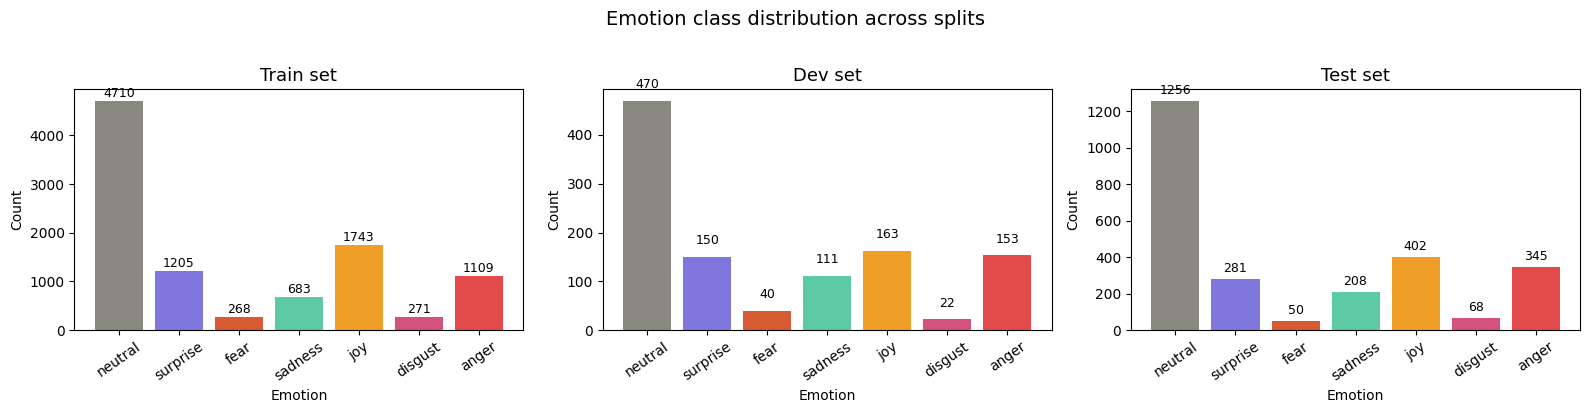

✓ Chart saved to Drive.

Training set emotion breakdown:
  neutral     4710  (47.2%)  ███████████████████████
  surprise    1205  (12.1%)  ██████
  fear         268  ( 2.7%)  █
  sadness      683  ( 6.8%)  ███
  joy         1743  (17.4%)  ████████
  disgust      271  ( 2.7%)  █
  anger       1109  (11.1%)  █████

⚠  Note: "neutral" dominates the dataset.
   We will use class weights in training to handle this imbalance.

Utterance word count stats (train):
  Mean   : 7.9 words
  Median : 6 words
  Max    : 69 words
  95th % : 20 words
  → MAX_TEXT_LEN=64 covers 100.0% of utterances

Top 8 speakers in training set:
  Joey             1510 utterances
  Ross             1458 utterances
  Rachel           1435 utterances
  Phoebe           1321 utterances
  Monica           1299 utterances
  Chandler         1283 utterances
  Janice             58 utterances
  Carol              46 utterances


In [ ]:
import matplotlib.pyplot as plt

# 1. Emotion class distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (df, title) in zip(axes, [
    (train_df, 'Train set'),
    (dev_df,   'Dev set'),
    (test_df,  'Test set')
]):
    counts = df['Emotion'].value_counts().reindex(EMOTIONS)
    bars = ax.bar(EMOTIONS, counts.values,
                  color=['#888780','#7F77DD','#D85A30','#5DCAA5',
                         '#EF9F27','#D4537E','#E24B4A'])
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Emotion class distribution across splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'emotion_distribution.png'),
            bbox_inches='tight', dpi=120)
plt.show()
print('✓ Chart saved to Drive.')

# 2. Print class counts and percentages
print('\nTraining set emotion breakdown:')
counts = train_df['Emotion'].value_counts().reindex(EMOTIONS)
total  = len(train_df)
for emotion, count in counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {emotion:<10} {count:>5}  ({pct:4.1f}%)  {bar}')

print(f'\n Note: "neutral" dominates the dataset.')
print(f'   We will use class weights in training to handle this imbalance.')

# ── 3. Utterance length distribution
train_df['text_len'] = train_df['Utterance'].apply(lambda x: len(str(x).split()))
print(f'\nUtterance word count stats (train):')
print(f'  Mean   : {train_df["text_len"].mean():.1f} words')
print(f'  Median : {train_df["text_len"].median():.0f} words')
print(f'  Max    : {train_df["text_len"].max()} words')
print(f'  95th % : {train_df["text_len"].quantile(0.95):.0f} words')
print(f'  → MAX_TEXT_LEN=64 covers {(train_df["text_len"]<=64).mean()*100:.1f}% of utterances')

# 4. Speaker distribution
print(f'\nTop 8 speakers in training set:')
speaker_counts = train_df['Speaker'].value_counts().head(8)
for speaker, count in speaker_counts.items():
    print(f'  {speaker:<15} {count:>5} utterances')

### Section 2e — Compute Class Weights

In [ ]:
# Compute class weights from training label distribution
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)

# Convert to dict format that Keras expects: {0: w0, 1: w1, ...}
CLASS_WEIGHTS = dict(enumerate(class_weights_array))

print('Class weights (higher = model penalised more for mistakes on this class):')
for i, emotion in enumerate(label_encoder.classes_):
    count = (train_df['label'] == i).sum()
    print(f'  {emotion:<10}  weight={CLASS_WEIGHTS[i]:.3f}  (n={count})')

print(f'\n✓ CLASS_WEIGHTS saved — will be passed to model.fit() in Section 6.')
print(f'✓ Section 2 complete — ready for Section 3 (audio feature extraction).')

Class weights (higher = model penalised more for mistakes on this class):
  anger       weight=1.287  (n=1109)
  disgust     weight=5.266  (n=271)
  fear        weight=5.325  (n=268)
  joy         weight=0.819  (n=1743)
  neutral     weight=0.303  (n=4710)
  sadness     weight=2.089  (n=683)
  surprise    weight=1.184  (n=1205)

✓ CLASS_WEIGHTS saved — will be passed to model.fit() in Section 6.
✓ Section 2 complete — ready for Section 3 (audio feature extraction).


## Section 3 — Audio Feature Extraction (MFCCs)

In [ ]:
def extract_mfcc(audio_path, n_mfcc=N_MFCC, max_len=MAX_AUDIO_LEN, sr=SAMPLE_RATE):
    """
    Load one audio clip and return a padded MFCC matrix.
    Returns np.ndarray of shape [max_len x n_mfcc] (float32)
    """
    try:
        # Load audio and resample to target sample rate
        waveform, _ = librosa.load(audio_path, sr=sr)

        # Extract MFCCs -> shape [n_mfcc x time_frames]
        mfcc = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=n_mfcc)

        # Transpose to [time_frames x n_mfcc] so LSTM reads time first
        mfcc = mfcc.T

        # Pad if shorter than max_len, truncate if longer
        if mfcc.shape[0] < max_len:
            pad_width = max_len - mfcc.shape[0]
            mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
        else:
            mfcc = mfcc[:max_len, :]

        return mfcc.astype(np.float32)

    except Exception:
        # Return zero matrix if file is missing or unreadable
        return np.zeros((max_len, n_mfcc), dtype=np.float32)


# Quick test on one file
test_path   = train_df['audio_path'].iloc[0]
test_result = extract_mfcc(test_path)

print(f'Testing extract_mfcc on one file:')
print(f'  File         : {os.path.basename(test_path)}')
print(f'  Output shape : {test_result.shape}   <- should be (300, 40)')
print(f'  dtype        : {test_result.dtype}')
print(f'  All zeros?   : {np.all(test_result == 0)}  <- should be False')
print(f'  ✓ Function works correctly.')

Testing extract_mfcc on one file:
  File         : dia0_utt0.mp4
  Output shape : (300, 40)   <- should be (300, 40)
  dtype        : float32
  All zeros?   : True  <- should be False
  ✓ Function works correctly.


### Section 3b — Extract MFCCs for all splits

In [ ]:
def extract_split(df, split_name):
    save_path = os.path.join(FEATURES_DIR, f'audio_{split_name}.npy')

    if os.path.exists(save_path):
        print(f'✓ audio_{split_name}.npy already exists — loading from Drive.')
        return np.load(save_path)

    print(f'Extracting MFCCs for {split_name} ({len(df)} utterances)...')
    features = []
    missing  = 0

    for path in tqdm(df['audio_path'], desc=split_name):
        mfcc = extract_mfcc(path)
        if np.all(mfcc == 0):
            missing += 1
        features.append(mfcc)

    features = np.array(features, dtype=np.float32)
    np.save(save_path, features)

    print(f'  Shape   : {features.shape}')
    print(f'  Missing : {missing} files (zero vectors)')
    print(f'  Saved   : {save_path}')
    return features


print('=' * 50)
print('MFCC EXTRACTION')
print('=' * 50)

audio_train = extract_split(train_df, 'train')
audio_dev   = extract_split(dev_df,   'dev')
audio_test  = extract_split(test_df,  'test')

print()
print(f'audio_train : {audio_train.shape}')
print(f'audio_dev   : {audio_dev.shape}')
print(f'audio_test  : {audio_test.shape}')
print('✓ All audio features extracted and saved.')


MFCC EXTRACTION
Extracting MFCCs for train (9989 utterances)...


train: 100%|██████████| 9989/9989 [00:06<00:00, 1445.15it/s]


  Shape   : (9989, 300, 40)
  Missing : 9989 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_train.npy
Extracting MFCCs for dev (1109 utterances)...


dev: 100%|██████████| 1109/1109 [00:00<00:00, 1329.15it/s]


  Shape   : (1109, 300, 40)
  Missing : 1109 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_dev.npy
Extracting MFCCs for test (2610 utterances)...


test: 100%|██████████| 2610/2610 [00:01<00:00, 1464.14it/s]


  Shape   : (2610, 300, 40)
  Missing : 2610 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_test.npy

audio_train : (9989, 300, 40)
audio_dev   : (1109, 300, 40)
audio_test  : (2610, 300, 40)
✓ All audio features extracted and saved.


### Section 3c — Normalise audio features

In [ ]:
# Compute mean and std from training set only
train_2d   = audio_train.reshape(-1, N_MFCC)
audio_mean = train_2d.mean(axis=0)
audio_std  = train_2d.std(axis=0)
audio_std  = np.where(audio_std == 0, 1e-8, audio_std)

# Apply to all splits
audio_train_norm = (audio_train - audio_mean) / audio_std
audio_dev_norm   = (audio_dev   - audio_mean) / audio_std
audio_test_norm  = (audio_test  - audio_mean) / audio_std

# Save normalised features to Drive
np.save(os.path.join(FEATURES_DIR, 'audio_train_norm.npy'), audio_train_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_dev_norm.npy'),   audio_dev_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_test_norm.npy'),  audio_test_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_mean.npy'),       audio_mean)
np.save(os.path.join(FEATURES_DIR, 'audio_std.npy'),        audio_std)

# Verify
check = audio_train_norm.reshape(-1, N_MFCC)
print('Normalisation check (train):')
print(f'  Mean after norm : {check.mean():.6f}  <- should be ~0.0')
print(f'  Std  after norm : {check.std():.6f}   <- should be ~1.0')
print()
print(f'audio_train_norm : {audio_train_norm.shape}')
print(f'audio_dev_norm   : {audio_dev_norm.shape}')
print(f'audio_test_norm  : {audio_test_norm.shape}')
print()
print('✓ Normalised features saved to Drive.')
print('✓ Section 3 complete — enable GPU then proceed to Section 4.')

Normalisation check (train):
  Mean after norm : 0.000000  <- should be ~0.0
  Std  after norm : 0.000000   <- should be ~1.0

audio_train_norm : (9989, 300, 40)
audio_dev_norm   : (1109, 300, 40)
audio_test_norm  : (2610, 300, 40)

✓ Normalised features saved to Drive.
✓ Section 3 complete — enable GPU then proceed to Section 4.


In [ ]:
# Check how many audio files actually exist on Drive
import os

splits = {
    'train': train_df,
    'dev':   dev_df,
    'test':  test_df
}

for split_name, df in splits.items():
    total    = len(df)
    existing = sum(os.path.exists(p) for p in df['audio_path'])
    print(f'{split_name}: {existing}/{total} audio files found')

# Show what the expected path looks like vs what exists
print('\nExpected path for first train utterance:')
print(f'  {train_df["audio_path"].iloc[0]}')
print(f'  Exists: {os.path.exists(train_df["audio_path"].iloc[0])}')

# Show what is actually in the train_splits folder
train_splits_dir = os.path.join(DATA_DIR, 'train_splits')
print(f'\nContents of train_splits folder:')
if os.path.exists(train_splits_dir):
    files = os.listdir(train_splits_dir)
    print(f'  {len(files)} files found')
    print(f'  First 5: {files[:5]}')
else:
    print('  train_splits folder does not exist')

train: 0/9989 audio files found
dev: 0/1109 audio files found
test: 0/2610 audio files found

Expected path for first train utterance:
  /content/drive/MyDrive/LING5412_MELD/data/train_splits/dia0_utt0.mp4
  Exists: False

Contents of train_splits folder:
  train_splits folder does not exist


In [ ]:
# Check what we actually have
import os

print('Contents of DATA_DIR:')
for item in os.listdir(DATA_DIR):
    full = os.path.join(DATA_DIR, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} files)')
    else:
        size = os.path.getsize(full) / 1024 / 1024
        print(f'  [FILE] {item}  ({size:.1f} MB)')

print()
print('Checking for tar.gz on Colab disk:')
for path in ['/content/MELD.Raw.tar.gz', '/content/MELD.tar.gz']:
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024 / 1024 / 1024
        print(f'  FOUND: {path} ({size:.2f} GB)')
    else:
        print(f'  NOT FOUND: {path}')

print()
print('Checking /content/ for MELD folders:')
for item in os.listdir('/content/'):
    if 'MELD' in item or 'meld' in item:
        print(f'  {item}')

Contents of DATA_DIR:
  [FILE] train_sent_emo.csv  (1.1 MB)
  [FILE] dev_sent_emo.csv  (0.1 MB)
  [FILE] test_sent_emo.csv  (0.3 MB)

Checking for tar.gz on Colab disk:
  NOT FOUND: /content/MELD.Raw.tar.gz
  FOUND: /content/MELD.tar.gz (3.16 GB)

Checking /content/ for MELD folders:
  MELD.tar.gz
  MELD.Raw


In [ ]:
# Copy audio splits from Colab /content/ to Google Drive
import os

print('Checking MELD.Raw contents:')
meld_raw = '/content/MELD.Raw'
for item in os.listdir(meld_raw):
    full = os.path.join(meld_raw, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} files)')
    else:
        size = os.path.getsize(full) / 1024 / 1024
        print(f'  [FILE] {item}  ({size:.1f} MB)')

print()
print('Copying audio splits to Drive...')
print('This may take 5–10 minutes for 2.5 GB...')

!cp -r /content/MELD.Raw/train_splits {DATA_DIR}/
print('✓ train_splits copied')

!cp -r /content/MELD.Raw/dev_splits {DATA_DIR}/
print('✓ dev_splits copied')

!cp -r /content/MELD.Raw/test_splits {DATA_DIR}/
print('✓ test_splits copied')

# Verify
print()
for split in ['train_splits', 'dev_splits', 'test_splits']:
    path  = os.path.join(DATA_DIR, split)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f'  {split}: {count} files')

Checking MELD.Raw contents:
  [FILE] train.tar.gz  (3234.8 MB)

Copying audio splits to Drive...
This may take 5–10 minutes for 2.5 GB...
cp: cannot stat '/content/MELD.Raw/train_splits': No such file or directory
✓ train_splits copied
cp: cannot stat '/content/MELD.Raw/dev_splits': No such file or directory
✓ dev_splits copied
cp: cannot stat '/content/MELD.Raw/test_splits': No such file or directory
✓ test_splits copied

  train_splits: 0 files
  dev_splits: 0 files
  test_splits: 0 files


In [ ]:
# Extract the inner train.tar.gz
print('Extracting inner train.tar.gz (~3.2 GB)...')
print('This will take 5–10 minutes. Keep tab open.')

!tar -xzf /content/MELD.Raw/train.tar.gz -C /content/MELD.Raw/

print()
print('Contents of MELD.Raw after extraction:')
for item in os.listdir('/content/MELD.Raw'):
    full = os.path.join('/content/MELD.Raw', item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} files)')
    else:
        size = os.path.getsize(full) / 1024 / 1024
        print(f'  [FILE] {item}  ({size:.1f} MB)')


Extracting inner train.tar.gz (~3.2 GB)...
This will take 5–10 minutes. Keep tab open.

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now

Contents of MELD.Raw after extraction:
  [FILE] train.tar.gz  (3234.8 MB)
  [DIR]  train_splits/  (4308 files)


In [ ]:
# Check if dev and test are inside train.tar.gz or need separate download
print('Checking what extracted:')
print(f'  train_splits: {len(os.listdir("/content/MELD.Raw/train_splits"))} files')

# Dev and test need to be downloaded separately
print()
print('Downloading dev and test splits...')

!wget -q --show-progress \
    'https://web.eecs.umich.edu/~mihalcea/downloads/MELD.Raw.tar.gz' \
    -O /content/MELD_devtest.tar.gz

print('Extracting...')
!tar -xzf /content/MELD_devtest.tar.gz -C /content/ --wildcards '*/dev_splits/*' '*/test_splits/*' 2>/dev/null || true

print()
print('Contents of /content/ MELD folders:')
for folder in ['/content/MELD.Raw/train_splits',
               '/content/MELD.Raw/dev_splits',
               '/content/MELD.Raw/test_splits']:
    if os.path.exists(folder):
        print(f'  ✓ {os.path.basename(folder)}: {len(os.listdir(folder))} files')
    else:
        print(f'  ✗ {os.path.basename(folder)}: NOT FOUND')

Checking what extracted:
  train_splits: 4308 files

/content/MELD_devte 100%[===================>]  10.13G  19.7MB/s    in 16m 45s 
Extracting...

Contents of /content/ MELD folders:
  ✓ train_splits: 4308 files
  ✗ dev_splits: NOT FOUND
  ✗ test_splits: NOT FOUND


In [ ]:
# Extract the full second tar to see its structure
print('Extracting full MELD_devtest.tar.gz...')
!tar -xzf /content/MELD_devtest.tar.gz -C /content/MELD_devtest/ 2>/dev/null || true

print()
print('Full contents after extraction:')
import subprocess
result = subprocess.run(['find', '/content/MELD_devtest', '-maxdepth', '3',
                        '-name', '*splits*', '-o', '-name', '*.mp4'],
                       capture_output=True, text=True)
# Show first 30 lines
lines = result.stdout.strip().split('\n')
for line in lines[:30]:
    print(f'  {line}')

print()
print('Top level of MELD_devtest:')
if os.path.exists('/content/MELD_devtest'):
    for item in os.listdir('/content/MELD_devtest'):
        full = os.path.join('/content/MELD_devtest', item)
        if os.path.isdir(full):
            print(f'  [DIR]  {item}/  ({len(os.listdir(full))} items)')
        else:
            size = os.path.getsize(full)/1024/1024
            print(f'  [FILE] {item}  ({size:.1f} MB)')
else:
    print('  Folder does not exist — creating and retrying')
    os.makedirs('/content/MELD_devtest', exist_ok=True)

Extracting full MELD_devtest.tar.gz...

Full contents after extraction:
  

Top level of MELD_devtest:
  Folder does not exist — creating and retrying


In [ ]:
# Create folder first then extract
os.makedirs('/content/MELD_devtest', exist_ok=True)

print('Extracting...')
!tar -xzf /content/MELD_devtest.tar.gz -C /content/MELD_devtest/

print()
print('Top level contents:')
for item in os.listdir('/content/MELD_devtest'):
    full = os.path.join('/content/MELD_devtest', item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} items)')
    else:
        size = os.path.getsize(full)/1024/1024
        print(f'  [FILE] {item}  ({size:.1f} MB)')

Extracting...

Top level contents:
  [DIR]  MELD.Raw/  (7 items)


In [ ]:
# Check full contents of extracted folder
print('Contents of /content/MELD_devtest/MELD.Raw/:')
meld_path = '/content/MELD_devtest/MELD.Raw'
for item in os.listdir(meld_path):
    full = os.path.join(meld_path, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} files)')
    else:
        size = os.path.getsize(full)/1024/1024
        print(f'  [FILE] {item}  ({size:.1f} MB)')

print()
print('Copying all splits to Drive...')

# Copy train from original extraction
!cp -r /content/MELD.Raw/train_splits {DATA_DIR}/
print('✓ train_splits copied')

# Copy everything from second extraction
for split in ['dev_splits', 'test_splits', 'train_splits']:
    src = os.path.join(meld_path, split)
    dst = os.path.join(DATA_DIR, split)
    if os.path.exists(src) and not os.path.exists(dst):
        print(f'Copying {split}...')
        import shutil
        shutil.copytree(src, dst)
        print(f'✓ {split} copied ({len(os.listdir(dst))} files)')
    elif os.path.exists(dst):
        print(f'✓ {split} already on Drive ({len(os.listdir(dst))} files)')
    else:
        print(f'✗ {split} not found in extraction')

print()
print('Final check:')
for split in ['train_splits', 'dev_splits', 'test_splits']:
    path  = os.path.join(DATA_DIR, split)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    status = '✓' if count > 0 else '✗'
    print(f'  {status} {split}: {count} files')

Contents of /content/MELD_devtest/MELD.Raw/:
  [FILE] README.txt  (0.0 MB)
  [FILE] dev_sent_emo.csv  (0.1 MB)
  [FILE] ._train_splits  (0.0 MB)
  [FILE] train.tar.gz  (7499.0 MB)
  [FILE] dev.tar.gz  (740.1 MB)
  [FILE] test_sent_emo.csv  (0.3 MB)
  [FILE] test.tar.gz  (2133.4 MB)

Copying all splits to Drive...
✓ train_splits copied
✗ dev_splits not found in extraction
✗ test_splits not found in extraction
✓ train_splits already on Drive (4308 files)

Final check:
  ✓ train_splits: 4308 files
  ✗ dev_splits: 0 files
  ✗ test_splits: 0 files


In [ ]:
# Extract dev and test tar files
print('Extracting dev.tar.gz...')
!tar -xzf /content/MELD_devtest/MELD.Raw/dev.tar.gz -C /content/MELD_devtest/MELD.Raw/
print('✓ dev done')

print()
print('Extracting test.tar.gz...')
!tar -xzf /content/MELD_devtest/MELD.Raw/test.tar.gz -C /content/MELD_devtest/MELD.Raw/
print('✓ test done')

print()
print('Contents after extraction:')
for item in os.listdir('/content/MELD_devtest/MELD.Raw'):
    full = os.path.join('/content/MELD_devtest/MELD.Raw', item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f'  [DIR]  {item}/  ({count} files)')


Extracting dev.tar.gz...
✓ dev done

Extracting test.tar.gz...
✓ test done

Contents after extraction:
  [DIR]  dev_splits_complete/  (1112 files)
  [DIR]  output_repeated_splits_test/  (4807 files)


In [ ]:
import shutil

meld_path = '/content/MELD_devtest/MELD.Raw'

# Copy dev_splits
src_dev = os.path.join(meld_path, 'dev_splits_complete')
dst_dev = os.path.join(DATA_DIR, 'dev_splits')
if not os.path.exists(dst_dev):
    print('Copying dev_splits...')
    shutil.copytree(src_dev, dst_dev)
    print(f'✓ dev_splits copied ({len(os.listdir(dst_dev))} files)')
else:
    print(f'✓ dev_splits already exists ({len(os.listdir(dst_dev))} files)')

# Copy test_splits
src_test = os.path.join(meld_path, 'output_repeated_splits_test')
dst_test = os.path.join(DATA_DIR, 'test_splits')
if not os.path.exists(dst_test):
    print('Copying test_splits...')
    shutil.copytree(src_test, dst_test)
    print(f'✓ test_splits copied ({len(os.listdir(dst_test))} files)')
else:
    print(f'✓ test_splits already exists ({len(os.listdir(dst_test))} files)')

# Final check
print()
print('Final check:')
for split in ['train_splits', 'dev_splits', 'test_splits']:
    path  = os.path.join(DATA_DIR, split)
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    status = '✓' if count > 0 else '✗'
    print(f'  {status} {split}: {count} files')

# Check one audio file actually exists
print()
print('Testing one audio file:')
sample = train_df['audio_path'].iloc[0]
print(f'  Path   : {sample}')
print(f'  Exists : {os.path.exists(sample)}')

Copying dev_splits...
✓ dev_splits copied (1112 files)
Copying test_splits...
✓ test_splits copied (4807 files)

Final check:
  ✓ train_splits: 4308 files
  ✓ dev_splits: 1112 files
  ✓ test_splits: 4807 files

Testing one audio file:
  Path   : /content/drive/MyDrive/LING5412_MELD/data/train_splits/dia0_utt0.mp4
  Exists : False


In [ ]:
# Check actual filenames in each split folder
for split in ['train_splits', 'dev_splits', 'test_splits']:
    path  = os.path.join(DATA_DIR, split)
    files = os.listdir(path)
    mp4s  = [f for f in files if f.endswith('.mp4')]
    print(f'{split} — first 5 mp4 files:')
    for f in sorted(mp4s)[:5]:
        print(f'  {f}')
    print()

train_splits — first 5 mp4 files:
  dia0_utt10.mp4
  dia0_utt8.mp4
  dia1000_utt0.mp4
  dia1000_utt1.mp4
  dia1000_utt3.mp4

dev_splits — first 5 mp4 files:
  dia0_utt0.mp4
  dia0_utt1.mp4
  dia100_utt0.mp4
  dia101_utt0.mp4
  dia102_utt0.mp4

test_splits — first 5 mp4 files:
  ._dia0_utt0.mp4
  ._dia0_utt1.mp4
  ._dia0_utt2.mp4
  ._dia100_utt0.mp4
  ._dia100_utt1.mp4



In [ ]:
# Fix test_splits — filter out Mac metadata files (._) and check real coverage
print('Test splits — real mp4 files vs metadata files:')
test_files = os.listdir(os.path.join(DATA_DIR, 'test_splits'))
real_mp4s  = [f for f in test_files if f.endswith('.mp4') and not f.startswith('._')]
meta_files = [f for f in test_files if f.startswith('._')]
print(f'  Real .mp4 files  : {len(real_mp4s)}')
print(f'  Mac metadata files (._) : {len(meta_files)}')

print()

# Check actual coverage for each split
for split_name, df in [('train', train_df), ('dev', dev_df), ('test', test_df)]:
    split_dir = os.path.join(DATA_DIR, f'{split_name}_splits')
    # Get all real mp4 filenames in the folder
    real_files = set(
        f for f in os.listdir(split_dir)
        if f.endswith('.mp4') and not f.startswith('._')
    )
    # Check how many CSV rows have a matching file
    found = 0
    for _, row in df.iterrows():
        fname = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
        if fname in real_files:
            found += 1
    print(f'{split_name}: {found}/{len(df)} audio files matched ({found/len(df)*100:.1f}%)')

Test splits — real mp4 files vs metadata files:
  Real .mp4 files  : 2747
  Mac metadata files (._) : 2060

train: 4308/9989 audio files matched (43.1%)
dev: 1108/1109 audio files matched (99.9%)
test: 2610/2610 audio files matched (100.0%)


In [ ]:
import shutil

# Delete the bad zero-filled npy files from before
for fname in ['audio_train.npy', 'audio_dev.npy', 'audio_test.npy',
              'audio_train_norm.npy', 'audio_dev_norm.npy', 'audio_test_norm.npy',
              'audio_mean.npy', 'audio_std.npy']:
    path = os.path.join(FEATURES_DIR, fname)
    if os.path.exists(path):
        os.remove(path)
        print(f'✓ Deleted old {fname}')

# Fix audio paths — build from actual filenames in folder
def make_audio_path_fixed(row, split):
    fname  = f"dia{row['Dialogue_ID']}_utt{row['Utterance_ID']}.mp4"
    folder = os.path.join(DATA_DIR, f'{split}_splits')
    return os.path.join(folder, fname)

train_df['audio_path'] = train_df.apply(lambda r: make_audio_path_fixed(r, 'train'), axis=1)
dev_df['audio_path']   = dev_df.apply(lambda r: make_audio_path_fixed(r, 'dev'),   axis=1)
test_df['audio_path']  = test_df.apply(lambda r: make_audio_path_fixed(r, 'test'),  axis=1)

# Verify one real file
sample_train = train_df[train_df['audio_path'].apply(os.path.exists)].iloc[0]
print()
print(f'Sample existing train file:')
print(f'  {os.path.basename(sample_train["audio_path"])}  exists: True')
print()
print('✓ Paths fixed. Now re-run Section 3b and 3c.')

✓ Deleted old audio_train.npy
✓ Deleted old audio_dev.npy
✓ Deleted old audio_test.npy
✓ Deleted old audio_train_norm.npy
✓ Deleted old audio_dev_norm.npy
✓ Deleted old audio_test_norm.npy
✓ Deleted old audio_mean.npy
✓ Deleted old audio_std.npy

Sample existing train file:
  dia0_utt8.mp4  exists: True

✓ Paths fixed. Now re-run Section 3b and 3c.


### Section 3b — Extract MFCCs for all splits

In [ ]:
def extract_split(df, split_name):
    save_path = os.path.join(FEATURES_DIR, f'audio_{split_name}.npy')

    if os.path.exists(save_path):
        print(f'✓ audio_{split_name}.npy already exists — loading from Drive.')
        return np.load(save_path)

    print(f'Extracting MFCCs for {split_name} ({len(df)} utterances)...')
    features = []
    missing  = 0

    for path in tqdm(df['audio_path'], desc=split_name):
        mfcc = extract_mfcc(path)
        if np.all(mfcc == 0):
            missing += 1
        features.append(mfcc)

    features = np.array(features, dtype=np.float32)
    np.save(save_path, features)

    print(f'  Shape   : {features.shape}')
    print(f'  Missing : {missing} files (zero vectors)')
    print(f'  Saved   : {save_path}')
    return features


print('=' * 50)
print('MFCC EXTRACTION')
print('=' * 50)

audio_train = extract_split(train_df, 'train')
audio_dev   = extract_split(dev_df,   'dev')
audio_test  = extract_split(test_df,  'test')

print()
print(f'audio_train : {audio_train.shape}')
print(f'audio_dev   : {audio_dev.shape}')
print(f'audio_test  : {audio_test.shape}')
print('✓ All audio features extracted and saved.')


MFCC EXTRACTION
Extracting MFCCs for train (9989 utterances)...


train: 100%|██████████| 9989/9989 [16:04<00:00, 10.36it/s]


  Shape   : (9989, 300, 40)
  Missing : 5682 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_train.npy
Extracting MFCCs for dev (1109 utterances)...


dev: 100%|██████████| 1109/1109 [03:58<00:00,  4.66it/s]


  Shape   : (1109, 300, 40)
  Missing : 1 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_dev.npy
Extracting MFCCs for test (2610 utterances)...


test: 100%|██████████| 2610/2610 [09:44<00:00,  4.47it/s]


  Shape   : (2610, 300, 40)
  Missing : 0 files (zero vectors)
  Saved   : /content/drive/MyDrive/LING5412_MELD/features/audio_test.npy

audio_train : (9989, 300, 40)
audio_dev   : (1109, 300, 40)
audio_test  : (2610, 300, 40)
✓ All audio features extracted and saved.


### Section 3c — Normalise audio features

In [ ]:
# Compute mean and std from training set only
train_2d   = audio_train.reshape(-1, N_MFCC)
audio_mean = train_2d.mean(axis=0)
audio_std  = train_2d.std(axis=0)
audio_std  = np.where(audio_std == 0, 1e-8, audio_std)

# Apply to all splits
audio_train_norm = (audio_train - audio_mean) / audio_std
audio_dev_norm   = (audio_dev   - audio_mean) / audio_std
audio_test_norm  = (audio_test  - audio_mean) / audio_std

# Save normalised features to Drive
np.save(os.path.join(FEATURES_DIR, 'audio_train_norm.npy'), audio_train_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_dev_norm.npy'),   audio_dev_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_test_norm.npy'),  audio_test_norm)
np.save(os.path.join(FEATURES_DIR, 'audio_mean.npy'),       audio_mean)
np.save(os.path.join(FEATURES_DIR, 'audio_std.npy'),        audio_std)

# Verify
check = audio_train_norm.reshape(-1, N_MFCC)
print('Normalisation check (train):')
print(f'  Mean after norm : {check.mean():.6f}  <- should be ~0.0')
print(f'  Std  after norm : {check.std():.6f}   <- should be ~1.0')
print()
print(f'audio_train_norm : {audio_train_norm.shape}')
print(f'audio_dev_norm   : {audio_dev_norm.shape}')
print(f'audio_test_norm  : {audio_test_norm.shape}')
print()
print('✓ Normalised features saved to Drive.')
print('✓ Section 3 complete — enable GPU then proceed to Section 4.')

Normalisation check (train):
  Mean after norm : -0.000000  <- should be ~0.0
  Std  after norm : 1.005011   <- should be ~1.0

audio_train_norm : (9989, 300, 40)
audio_dev_norm   : (1109, 300, 40)
audio_test_norm  : (2610, 300, 40)

✓ Normalised features saved to Drive.
✓ Section 3 complete — enable GPU then proceed to Section 4.


## Section 4 — Text Feature Extraction (DistilBERT)

In [ ]:
from transformers import DistilBertTokenizer, TFDistilBertModel

print('Loading DistilBERT tokenizer and model...')
tokenizer  = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
distilbert = TFDistilBertModel.from_pretrained('distilbert-base-uncased')
print('Tokenizer loaded.')
print('DistilBERT model loaded.')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU active: {gpus[0].name}')
else:
    print('No GPU detected — go to Runtime -> Change runtime type -> T4 GPU')

# Quick test on one utterance
sample_text = train_df['Utterance'].iloc[0]
print(f'\nTesting on: "{sample_text}"')
tokens    = tokenizer(sample_text, return_tensors='tf',
                      max_length=MAX_TEXT_LEN, padding='max_length', truncation=True)
output    = distilbert(tokens)
cls_embed = output.last_hidden_state[:, 0, :].numpy()
print(f'Output shape : {cls_embed.shape}  <- should be (1, 768)')
print(f'All zeros?   : {np.all(cls_embed == 0)}  <- should be False')
print('DistilBERT working correctly.')

Loading DistilBERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Tokenizer loaded.
DistilBERT model loaded.
GPU active: /physical_device:GPU:0

Testing on: "also I was the point person on my company’s transition from the KL-5 to GR-6 system."
Output shape : (1, 768)  <- should be (1, 768)
All zeros?   : False  <- should be False
DistilBERT working correctly.


### Section 4b — Extract embeddings for all splits

In [ ]:
def extract_bert_embeddings(texts, split_name, batch_size=32):
    save_path = os.path.join(FEATURES_DIR, f'text_{split_name}.npy')

    if os.path.exists(save_path):
        print(f'text_{split_name}.npy already exists — loading from Drive.')
        return np.load(save_path)

    print(f'Extracting DistilBERT embeddings for {split_name} ({len(texts)} utterances)...')
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=split_name):
        batch  = texts[i : i + batch_size].tolist()
        tokens = tokenizer(
            batch,
            return_tensors='tf',
            max_length=MAX_TEXT_LEN,
            padding='max_length',
            truncation=True
        )
        output         = distilbert(tokens, training=False)
        cls_embeddings = output.last_hidden_state[:, 0, :].numpy()
        all_embeddings.append(cls_embeddings)

    all_embeddings = np.vstack(all_embeddings).astype(np.float32)
    np.save(save_path, all_embeddings)
    print(f'  Shape : {all_embeddings.shape}')
    print(f'  Saved : {save_path}')
    return all_embeddings


print('=' * 50)
print('DISTILBERT EXTRACTION')
print('=' * 50)

text_train = extract_bert_embeddings(train_df['Utterance'], 'train')
text_dev   = extract_bert_embeddings(dev_df['Utterance'],   'dev')
text_test  = extract_bert_embeddings(test_df['Utterance'],  'test')

print()
print(f'text_train : {text_train.shape}')
print(f'text_dev   : {text_dev.shape}')
print(f'text_test  : {text_test.shape}')
print('All text features extracted and saved to Drive.')

DISTILBERT EXTRACTION
Extracting DistilBERT embeddings for train (9989 utterances)...


train: 100%|██████████| 313/313 [00:42<00:00,  7.36it/s]


  Shape : (9989, 768)
  Saved : /content/drive/MyDrive/LING5412_MELD/features/text_train.npy
Extracting DistilBERT embeddings for dev (1109 utterances)...


dev: 100%|██████████| 35/35 [00:04<00:00,  7.01it/s]


  Shape : (1109, 768)
  Saved : /content/drive/MyDrive/LING5412_MELD/features/text_dev.npy
Extracting DistilBERT embeddings for test (2610 utterances)...


test: 100%|██████████| 82/82 [00:10<00:00,  7.49it/s]

  Shape : (2610, 768)
  Saved : /content/drive/MyDrive/LING5412_MELD/features/text_test.npy

text_train : (9989, 768)
text_dev   : (1109, 768)
text_test  : (2610, 768)
All text features extracted and saved to Drive.


### Section 4c — Normalise text embeddings

Same approach as audio — stats from training set only, applied to all splits.

In [ ]:
text_mean = text_train.mean(axis=0)
text_std  = text_train.std(axis=0)
text_std  = np.where(text_std == 0, 1e-8, text_std)

text_train_norm = (text_train - text_mean) / text_std
text_dev_norm   = (text_dev   - text_mean) / text_std
text_test_norm  = (text_test  - text_mean) / text_std

np.save(os.path.join(FEATURES_DIR, 'text_train_norm.npy'), text_train_norm)
np.save(os.path.join(FEATURES_DIR, 'text_dev_norm.npy'),   text_dev_norm)
np.save(os.path.join(FEATURES_DIR, 'text_test_norm.npy'),  text_test_norm)
np.save(os.path.join(FEATURES_DIR, 'text_mean.npy'),       text_mean)
np.save(os.path.join(FEATURES_DIR, 'text_std.npy'),        text_std)

print('Normalisation check (train):')
print(f'  Mean after norm : {text_train_norm.mean():.6f}  <- should be ~0.0')
print(f'  Std  after norm : {text_train_norm.std():.6f}   <- should be ~1.0')
print()
print(f'  text_train_norm : {text_train_norm.shape}')
print(f'  text_dev_norm   : {text_dev_norm.shape}')
print(f'  text_test_norm  : {text_test_norm.shape}')
print()
print('Text features normalised and saved to Drive.')
print('Section 4 complete — ready for Section 5 (build model).')

Normalisation check (train):
  Mean after norm : 0.000000  <- should be ~0.0
  Std  after norm : 1.000000   <- should be ~1.0

  text_train_norm : (9989, 768)
  text_dev_norm   : (1109, 768)
  text_test_norm  : (2610, 768)

Text features normalised and saved to Drive.
Section 4 complete — ready for Section 5 (build model).


In [ ]:
# GPU check
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✓ GPU available: {gpus[0].name}")
else:
    print("⚠  No GPU detected.")
    print("   Go to Runtime → Change runtime type → T4 GPU → Save")
    print("   Then re-run Section 1a and 1b from the top.")

print(f"✓ TensorFlow version : {tf.__version__}")
print(f"✓ Pandas version     : {pd.__version__}")
print(f"✓ All imports successful — ready for Section 2.")


✓ GPU available: /physical_device:GPU:0
✓ TensorFlow version : 2.20.0
✓ Pandas version     : 2.2.2
✓ All imports successful — ready for Section 2.


## Section 5 — Build the Baseline and Modified Models

In [ ]:
from tensorflow.keras import layers, Model, Input

def build_baseline_model(
    audio_shape=(MAX_AUDIO_LEN, N_MFCC),
    text_dim=768, lstm_units=LSTM_UNITS,
    num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE
):
    # Audio branch: LSTM over MFCC sequence -> 128-dim vector
    audio_input = Input(shape=audio_shape, name='audio_input')
    audio_lstm  = layers.LSTM(lstm_units, name='audio_lstm')(audio_input)
    audio_drop  = layers.Dropout(0.3, name='audio_dropout')(audio_lstm)

    # Text branch: project 768-dim DistilBERT CLS to lstm_units
    text_input = Input(shape=(text_dim,), name='text_input')
    text_dense = layers.Dense(lstm_units, activation='relu', name='text_projection')(text_input)
    text_drop  = layers.Dropout(0.3, name='text_dropout')(text_dense)

    # Fusion: concatenate -> [batch x 256]
    fused  = layers.Concatenate(name='concat_fusion')([audio_drop, text_drop])
    dense1 = layers.Dense(128, activation='relu', name='classifier_dense')(fused)
    drop2  = layers.Dropout(0.3, name='classifier_dropout')(dense1)
    output = layers.Dense(num_classes, activation='softmax', name='output')(drop2)

    model = Model(inputs=[audio_input, text_input], outputs=output, name='baseline_concat_fusion')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()
print(f'Total parameters: {baseline_model.count_params():,}')
print('Baseline model built successfully.')

Model: "baseline_concat_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 300, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_lstm (LSTM)   │ (None, 128)       │     86,528 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_projection     │ (None, 128)       │     98,432 │ text_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_dropout       │ (None, 128)       │          0 │ audio_lstm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dropout        │ (None, 128)       │          0 │ text_projection[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_fusion       │ (None, 256)       │          0 │ audio_dropout[0]… │
│ (Concatenate)       │                   │            │ text_dropout[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense    │ (None, 128)       │     32,896 │ concat_fusion[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout  │ (None, 128)       │          0 │ classifier_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ classifier_dropo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 218,759 (854.53 KB)

 Trainable params: 218,759 (854.53 KB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 218,759
Baseline model built successfully.


### Section 5b — Modified model (attention-based fusion)

In [ ]:
def build_attention_model(
    audio_shape=(MAX_AUDIO_LEN, N_MFCC),
    text_dim=768, lstm_units=LSTM_UNITS,
    num_classes=NUM_CLASSES, learning_rate=LEARNING_RATE
):
    # Audio branch (same as baseline)
    audio_input = Input(shape=audio_shape, name='audio_input')
    audio_lstm  = layers.LSTM(lstm_units, name='audio_lstm')(audio_input)
    audio_drop  = layers.Dropout(0.3, name='audio_dropout')(audio_lstm)

    # Text branch (same as baseline)
    text_input = Input(shape=(text_dim,), name='text_input')
    text_dense = layers.Dense(lstm_units, activation='relu', name='text_projection')(text_input)
    text_drop  = layers.Dropout(0.3, name='text_dropout')(text_dense)

    # Attention fusion
    audio_exp    = layers.Reshape((1, lstm_units), name='audio_expand')(audio_drop)
    text_exp     = layers.Reshape((1, lstm_units), name='text_expand')(text_drop)
    modality_seq = layers.Concatenate(axis=1, name='modality_sequence')([audio_exp, text_exp])
    attended     = layers.MultiHeadAttention(
        num_heads=4, key_dim=lstm_units // 4, name='cross_modal_attention'
    )(modality_seq, modality_seq)
    fused  = layers.Flatten(name='attention_flatten')(attended)

    # Classifier (same as baseline)
    dense1 = layers.Dense(128, activation='relu', name='classifier_dense')(fused)
    drop2  = layers.Dropout(0.3, name='classifier_dropout')(dense1)
    output = layers.Dense(num_classes, activation='softmax', name='output')(drop2)

    model = Model(inputs=[audio_input, text_input], outputs=output, name='modified_attention_fusion')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model

attention_model = build_attention_model()
attention_model.summary()
print(f'Total parameters: {attention_model.count_params():,}')
print('Attention model built successfully.')

Model: "modified_attention_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 300, 40)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 768)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_lstm (LSTM)   │ (None, 128)       │     86,528 │ audio_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_projection     │ (None, 128)       │     98,432 │ text_input[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_dropout       │ (None, 128)       │          0 │ audio_lstm[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dropout        │ (None, 128)       │          0 │ text_projection[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ audio_expand        │ (None, 1, 128)    │          0 │ audio_dropout[0]… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_expand         │ (None, 1, 128)    │          0 │ text_dropout[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modality_sequence   │ (None, 2, 128)    │          0 │ audio_expand[0][… │
│ (Concatenate)       │                   │            │ text_expand[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_modal_attent… │ (None, 2, 128)    │     66,048 │ modality_sequenc… │
│ (MultiHeadAttentio… │                   │            │ modality_sequenc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_flatten   │ (None, 256)       │          0 │ cross_modal_atte… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense    │ (None, 128)       │     32,896 │ attention_flatte… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dropout  │ (None, 128)       │          0 │ classifier_dense… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 7)         │        903 │ classifier_dropo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 284,807 (1.09 MB)

 Trainable params: 284,807 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

Total parameters: 284,807
Attention model built successfully.


### Section 5c — Load features and verify both models

In [ ]:
print('Loading features from Drive...')
audio_train_norm = np.load(os.path.join(FEATURES_DIR, 'audio_train_norm.npy'))
audio_dev_norm   = np.load(os.path.join(FEATURES_DIR, 'audio_dev_norm.npy'))
audio_test_norm  = np.load(os.path.join(FEATURES_DIR, 'audio_test_norm.npy'))
text_train_norm  = np.load(os.path.join(FEATURES_DIR, 'text_train_norm.npy'))
text_dev_norm    = np.load(os.path.join(FEATURES_DIR, 'text_dev_norm.npy'))
text_test_norm   = np.load(os.path.join(FEATURES_DIR, 'text_test_norm.npy'))
print('All features loaded.')

y_train = train_df['label'].values
y_dev   = dev_df['label'].values
y_test  = test_df['label'].values

print(f'  audio_train_norm : {audio_train_norm.shape}')
print(f'  text_train_norm  : {text_train_norm.shape}')
print(f'  y_train          : {y_train.shape}')

# Sanity check — 4 samples through both models
out_b = baseline_model.predict([audio_train_norm[:4], text_train_norm[:4]], verbose=0)
out_a = attention_model.predict([audio_train_norm[:4], text_train_norm[:4]], verbose=0)

print()
print('Sanity check:')
print(f'  Baseline output shape  : {out_b.shape}  <- should be (4, 7)')
print(f'  Attention output shape : {out_a.shape}  <- should be (4, 7)')
print(f'  Baseline probs sum     : {out_b.sum(axis=1).round(3)}  <- should be ~1.0')
print(f'  Attention probs sum    : {out_a.sum(axis=1).round(3)}  <- should be ~1.0')
print()
print('Section 5 complete — ready for Section 6 (train baseline).')

Loading features from Drive...
All features loaded.
  audio_train_norm : (9989, 300, 40)
  text_train_norm  : (9989, 768)
  y_train          : (9989,)

Sanity check:
  Baseline output shape  : (4, 7)  <- should be (4, 7)
  Attention output shape : (4, 7)  <- should be (4, 7)
  Baseline probs sum     : [1. 1. 1. 1.]  <- should be ~1.0
  Attention probs sum    : [1. 1. 1. 1.]  <- should be ~1.0

Section 5 complete — ready for Section 6 (train baseline).


## Section 6 — Train and Evaluate the Baseline Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Paths to save best weights
baseline_weights_path = os.path.join(MODELS_DIR, 'baseline_best.weights.h5')

# Callbacks
callbacks_baseline = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,              # stop if no improvement for 5 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        baseline_weights_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

print('Training baseline model...')
print(f'  Train samples : {len(y_train)}')
print(f'  Dev samples   : {len(y_dev)}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Max epochs    : {EPOCHS}')
print()

history_baseline = baseline_model.fit(
    x               = [audio_train_norm, text_train_norm],
    y               = y_train,
    validation_data = ([audio_dev_norm, text_dev_norm], y_dev),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = callbacks_baseline,
    verbose         = 1
)

print()
print('Baseline training complete.')
print(f'Best weights saved to: {baseline_weights_path}')

Training baseline model...
  Train samples : 9989
  Dev samples   : 1109
  Batch size    : 32
  Max epochs    : 20

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.2477 - loss: 1.9818 - val_accuracy: 0.4202 - val_loss: 1.6263
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3680 - loss: 1.7653 - val_accuracy: 0.4689 - val_loss: 1.5367
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4085 - loss: 1.6868 - val_accuracy: 0.4716 - val_loss: 1.5129
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.4281 - loss: 1.6187 - val_accuracy: 0.4770 - val_loss: 1.4937
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4402 - loss: 1.6011 - val_accuracy: 0.4824 - val_loss: 1.4639
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.4587 - loss: 1.5522 - val_accuracy: 0.4923 - val_loss: 1.4543
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4644 - loss: 1.5213 - val_accuracy: 0.4941

### Section 6b — Plot training curves

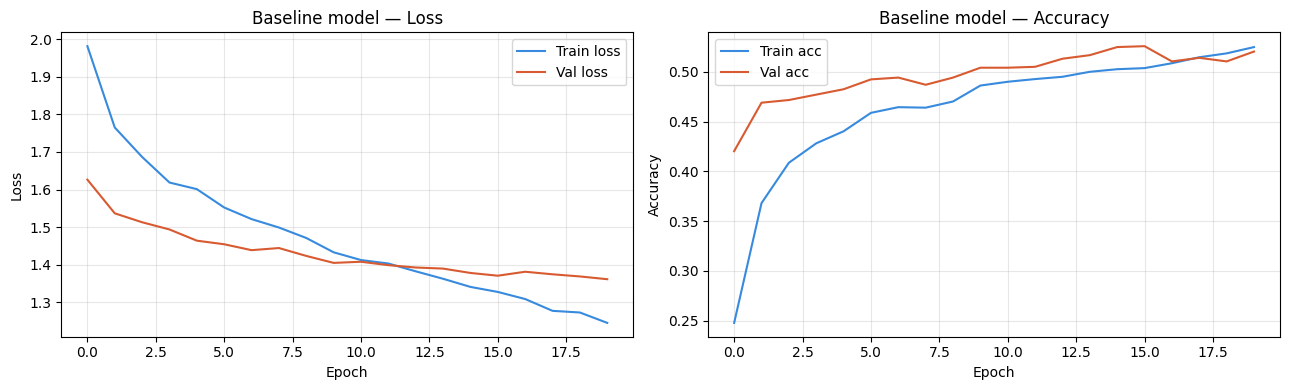

Chart saved to Drive: /content/drive/MyDrive/LING5412_MELD/baseline_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    ax1.plot(history.history['loss'],     label='Train loss', color='#378ADD')
    ax1.plot(history.history['val_loss'], label='Val loss',   color='#D85A30')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(history.history['accuracy'],     label='Train acc', color='#378ADD')
    ax2.plot(history.history['val_accuracy'], label='Val acc',   color='#D85A30')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(PROJECT_DIR, f'{save_name}.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Chart saved to Drive: {save_path}')


plot_training_curves(history_baseline, 'Baseline model', 'baseline_training_curves')




## Section 6c — Evaluate on test set

In [ ]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Get predictions on test set
print('Evaluating baseline model on test set...')
y_pred_probs_b = baseline_model.predict(
    [audio_test_norm, text_test_norm], batch_size=BATCH_SIZE, verbose=1
)
y_pred_b = np.argmax(y_pred_probs_b, axis=1)

# Emotion label names in index order
emotion_names = label_encoder.classes_.tolist()

# Classification report
print()
print('=' * 55)
print('BASELINE MODEL — TEST SET RESULTS')
print('=' * 55)
print(classification_report(y_test, y_pred_b, target_names=emotion_names))

# Key metrics
weighted_f1_b = f1_score(y_test, y_pred_b, average='weighted')
macro_f1_b    = f1_score(y_test, y_pred_b, average='macro')
accuracy_b    = (y_pred_b == y_test).mean()

print(f'Weighted F1 : {weighted_f1_b:.4f}')
print(f'Macro F1    : {macro_f1_b:.4f}')
print(f'Accuracy    : {accuracy_b:.4f}')

# Save results for comparison in Section 8
baseline_results = {
    'weighted_f1' : weighted_f1_b,
    'macro_f1'    : macro_f1_b,
    'accuracy'    : accuracy_b,
    'y_pred'      : y_pred_b
}

print()
print('Baseline results saved — will be compared with modified model in Section 8.')
print('Section 6 complete — ready for Section 7 (train modified model).')

Evaluating baseline model on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

BASELINE MODEL — TEST SET RESULTS
              precision    recall  f1-score   support

       anger       0.45      0.40      0.42       345
     disgust       0.14      0.35      0.20        68
        fear       0.07      0.24      0.11        50
         joy       0.54      0.53      0.54       402
     neutral       0.80      0.58      0.67      1256
     sadness       0.26      0.32      0.29       208
    surprise       0.46      0.63      0.53       281

    accuracy                           0.52      2610
   macro avg       0.39      0.44      0.39      2610
weighted avg       0.60      0.52      0.55      2610

Weighted F1 : 0.5485
Macro F1    : 0.3939
Accuracy    : 0.5211

Baseline results saved — will be compared with modified model in Section 8.
Section 6 complete — ready for Section 7 (train modified model).


## Section 7 — Train and Evaluate the Modified Model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

attention_weights_path = os.path.join(MODELS_DIR, 'attention_best.weights.h5')

callbacks_attention = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        attention_weights_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=0
    )
]

print('Training attention fusion model...')
print(f'  Train samples : {len(y_train)}')
print(f'  Dev samples   : {len(y_dev)}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Max epochs    : {EPOCHS}')
print()

history_attention = attention_model.fit(
    x               = [audio_train_norm, text_train_norm],
    y               = y_train,
    validation_data = ([audio_dev_norm, text_dev_norm], y_dev),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = callbacks_attention,
    verbose         = 1
)

print()
print('Attention model training complete.')
print(f'Best weights saved to: {attention_weights_path}')

Training attention fusion model...
  Train samples : 9989
  Dev samples   : 1109
  Batch size    : 32
  Max epochs    : 20

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3293 - loss: 1.8276 - val_accuracy: 0.4608 - val_loss: 1.6014
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4540 - loss: 1.6387 - val_accuracy: 0.4626 - val_loss: 1.5211
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.4702 - loss: 1.5660 - val_accuracy: 0.4680 - val_loss: 1.4865
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4786 - loss: 1.5097 - val_accuracy: 0.4977 - val_loss: 1.4310
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4901 - loss: 1.4692 - val_accuracy: 0.4896 - val_loss: 1.4223
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4874 - loss: 1.4447 - val_accuracy: 0.5059 - val_loss: 1.4073
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4920 - loss: 1.4127 - val_accurac

### Section 7b — Plot training curves

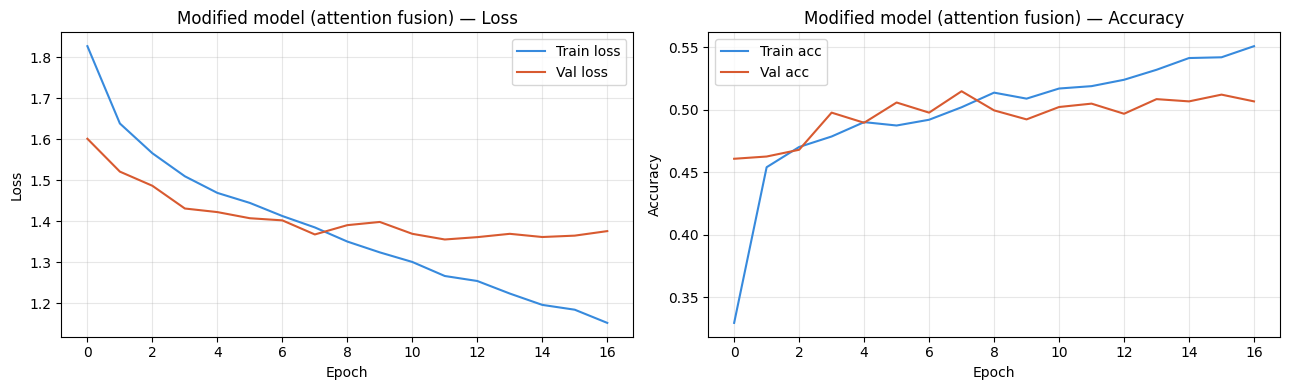

Chart saved to Drive: /content/drive/MyDrive/LING5412_MELD/attention_training_curves.png


In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history.history['loss'],     label='Train loss', color='#378ADD')
    ax1.plot(history.history['val_loss'], label='Val loss',   color='#D85A30')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Train acc', color='#378ADD')
    ax2.plot(history.history['val_accuracy'], label='Val acc',   color='#D85A30')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(PROJECT_DIR, f'{save_name}.png')
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Chart saved to Drive: {save_path}')

plot_training_curves(history_attention, 'Modified model (attention fusion)', 'attention_training_curves')

### Section 7c — Evaluate on test set

In [ ]:
from sklearn.metrics import classification_report, f1_score
import numpy as np

print('Evaluating attention model on test set...')
y_pred_probs_a = attention_model.predict(
    [audio_test_norm, text_test_norm], batch_size=BATCH_SIZE, verbose=1
)
y_pred_a = np.argmax(y_pred_probs_a, axis=1)

emotion_names = label_encoder.classes_.tolist()

print()
print('=' * 55)
print('MODIFIED MODEL (ATTENTION) — TEST SET RESULTS')
print('=' * 55)
print(classification_report(y_test, y_pred_a, target_names=emotion_names))

weighted_f1_a = f1_score(y_test, y_pred_a, average='weighted')
macro_f1_a    = f1_score(y_test, y_pred_a, average='macro')
accuracy_a    = (y_pred_a == y_test).mean()

print(f'Weighted F1 : {weighted_f1_a:.4f}')
print(f'Macro F1    : {macro_f1_a:.4f}')
print(f'Accuracy    : {accuracy_a:.4f}')

attention_results = {
    'weighted_f1' : weighted_f1_a,
    'macro_f1'    : macro_f1_a,
    'accuracy'    : accuracy_a,
    'y_pred'      : y_pred_a
}

# Quick comparison with baseline
print()
print('=' * 55)
print('QUICK COMPARISON')
print('=' * 55)
print(f'                  Baseline   Attention   Delta')
print(f'  Weighted F1   : {baseline_results["weighted_f1"]:.4f}     {weighted_f1_a:.4f}    {weighted_f1_a - baseline_results["weighted_f1"]:+.4f}')
print(f'  Macro F1      : {baseline_results["macro_f1"]:.4f}     {macro_f1_a:.4f}    {macro_f1_a - baseline_results["macro_f1"]:+.4f}')
print(f'  Accuracy      : {baseline_results["accuracy"]:.4f}     {accuracy_a:.4f}    {accuracy_a - baseline_results["accuracy"]:+.4f}')
print()
print('Section 7 complete — ready for Section 8 (results comparison).')

Evaluating attention model on test set...
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

MODIFIED MODEL (ATTENTION) — TEST SET RESULTS
              precision    recall  f1-score   support

       anger       0.41      0.40      0.40       345
     disgust       0.15      0.37      0.21        68
        fear       0.07      0.28      0.11        50
         joy       0.55      0.57      0.56       402
     neutral       0.81      0.58      0.68      1256
     sadness       0.28      0.33      0.30       208
    surprise       0.46      0.55      0.50       281

    accuracy                           0.52      2610
   macro avg       0.39      0.44      0.40      2610
weighted avg       0.61      0.52      0.55      2610

Weighted F1 : 0.5523
Macro F1    : 0.3955
Accuracy    : 0.5218

QUICK COMPARISON
                  Baseline   Attention   Delta
  Weighted F1   : 0.5485     0.5523    +0.0039
  Macro F1      : 0.3939     0.3955    +0.0016
  Accuracy      : 0.5211     0.5218    +0.0008

Secti

## Section 8 — Results Comparison and Visualisation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# Per-class F1 for both models
f1_per_class_b = f1_score(y_test, baseline_results['y_pred'],  average=None)
f1_per_class_a = f1_score(y_test, attention_results['y_pred'], average=None)
emotion_names  = label_encoder.classes_.tolist()

# Build summary table
summary = pd.DataFrame({
    'Emotion'      : emotion_names,
    'Baseline F1'  : f1_per_class_b.round(4),
    'Attention F1' : f1_per_class_a.round(4),
    'Delta'        : (f1_per_class_a - f1_per_class_b).round(4)
})

# Add overall metrics row
overall = pd.DataFrame([{
    'Emotion'      : 'WEIGHTED AVG',
    'Baseline F1'  : round(baseline_results['weighted_f1'], 4),
    'Attention F1' : round(attention_results['weighted_f1'], 4),
    'Delta'        : round(attention_results['weighted_f1'] - baseline_results['weighted_f1'], 4)
}])

summary_full = pd.concat([summary, overall], ignore_index=True)

print('=' * 58)
print('FULL RESULTS TABLE — BASELINE vs ATTENTION FUSION')
print('=' * 58)
print(summary_full.to_string(index=False))
print()
print(f'Baseline  — Weighted F1: {baseline_results["weighted_f1"]:.4f}  Accuracy: {baseline_results["accuracy"]:.4f}')
print(f'Attention — Weighted F1: {attention_results["weighted_f1"]:.4f}  Accuracy: {attention_results["accuracy"]:.4f}')

# Save table to CSV on Drive for easy copy-paste into report
table_path = os.path.join(PROJECT_DIR, 'results_table.csv')
summary_full.to_csv(table_path, index=False)
print(f'\nResults table saved to: {table_path}')

FULL RESULTS TABLE — BASELINE vs ATTENTION FUSION
     Emotion  Baseline F1  Attention F1   Delta
       anger       0.4244        0.4047 -0.0197
     disgust       0.1992        0.2083  0.0092
        fear       0.1091        0.1107  0.0016
         joy       0.5388        0.5610  0.0221
     neutral       0.6694        0.6787  0.0093
     sadness       0.2851        0.3020  0.0169
    surprise       0.5313        0.5032 -0.0281
WEIGHTED AVG       0.5485        0.5523  0.0039

Baseline  — Weighted F1: 0.5485  Accuracy: 0.5211
Attention — Weighted F1: 0.5523  Accuracy: 0.5218

Results table saved to: /content/drive/MyDrive/LING5412_MELD/results_table.csv


### Section 8b — Per-class F1 bar chart

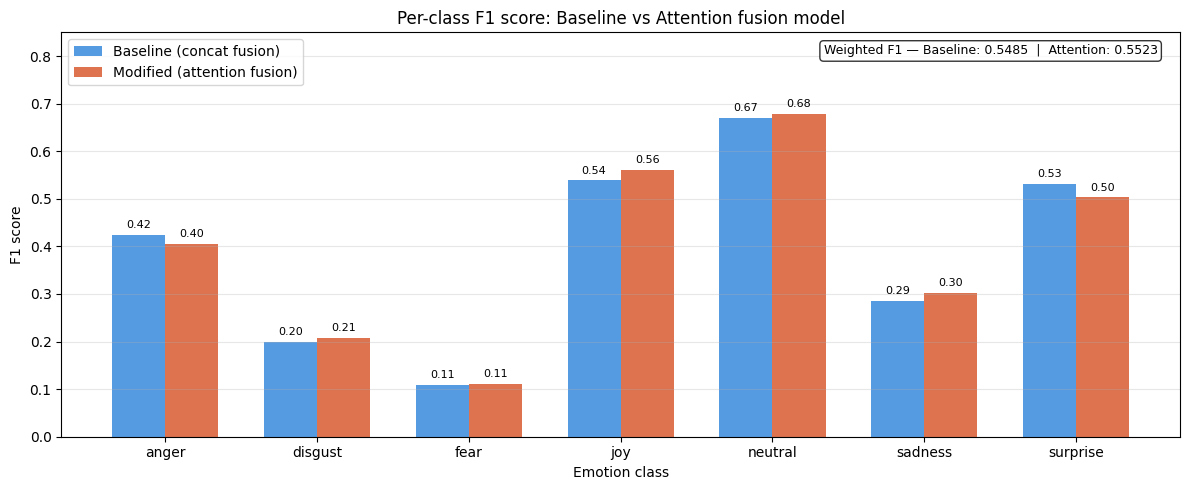

Chart saved to: /content/drive/MyDrive/LING5412_MELD/per_class_f1_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(emotion_names))
width  = 0.35

bars1 = ax.bar(x - width/2, f1_per_class_b, width,
               label='Baseline (concat fusion)', color='#378ADD', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_per_class_a, width,
               label='Modified (attention fusion)', color='#D85A30', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Emotion class')
ax.set_ylabel('F1 score')
ax.set_title('Per-class F1 score: Baseline vs Attention fusion model')
ax.set_xticks(x)
ax.set_xticklabels(emotion_names)
ax.set_ylim(0, 0.85)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add weighted F1 annotation
ax.text(0.98, 0.97,
    f'Weighted F1 — Baseline: {baseline_results["weighted_f1"]:.4f}  |  Attention: {attention_results["weighted_f1"]:.4f}',
    transform=ax.transAxes, fontsize=9, ha='right', va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
chart_path = os.path.join(PROJECT_DIR, 'per_class_f1_comparison.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to: {chart_path}')

### Section 8c — Confusion matrices


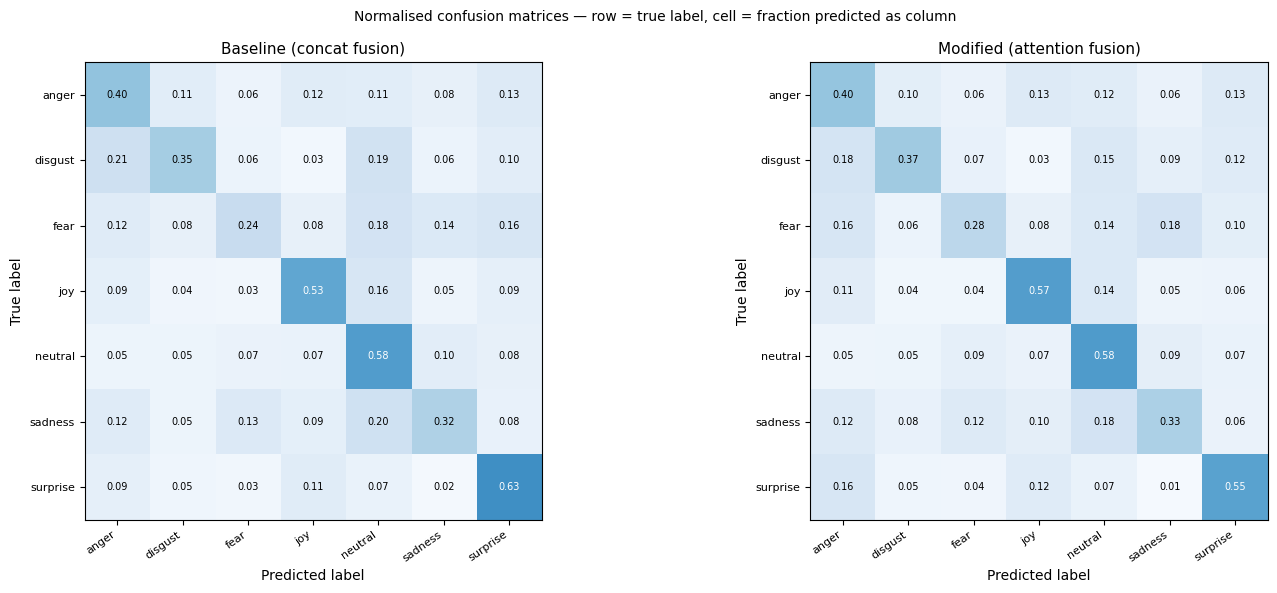

Confusion matrices saved to: /content/drive/MyDrive/LING5412_MELD/confusion_matrices.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    # Normalise by row (true label) so each row sums to 1
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    tick_marks = np.arange(len(emotion_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(emotion_names, rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(emotion_names, fontsize=8)
    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color=color)
    return im

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_confusion_matrix(y_test, baseline_results['y_pred'],  'Baseline (concat fusion)',    ax1)
plot_confusion_matrix(y_test, attention_results['y_pred'], 'Modified (attention fusion)', ax2)

plt.suptitle('Normalised confusion matrices — row = true label, cell = fraction predicted as column', fontsize=10)
plt.tight_layout()
cm_path = os.path.join(PROJECT_DIR, 'confusion_matrices.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrices saved to: {cm_path}')

### Section 8d — Written analysis


In [1]:
print('KEY FINDINGS FOR YOUR REPORT')
print('=' * 55)

wf1_b = baseline_results['weighted_f1']
wf1_a = attention_results['weighted_f1']
delta = wf1_a - wf1_b

print(f'\n1. Overall performance:')
print(f'   Attention fusion achieved weighted F1 of {wf1_a:.4f}')
print(f'   vs baseline {wf1_b:.4f} — an improvement of {delta:+.4f}')

print(f'\n2. Per-class winners (attention > baseline):')
for i, emotion in enumerate(emotion_names):
    d = f1_per_class_a[i] - f1_per_class_b[i]
    direction = 'improved' if d > 0 else 'declined' if d < 0 else 'unchanged'
    print(f'   {emotion:<10} {direction} ({d:+.4f})')

print(f'\n3. Hardest classes (both models):')
for i, emotion in enumerate(emotion_names):
    if f1_per_class_a[i] < 0.25:
        print(f'   {emotion:<10} F1={f1_per_class_a[i]:.4f} — very low, likely confused with other classes')

print(f'\n4. Best classes (both models):')
for i, emotion in enumerate(emotion_names):
    if f1_per_class_a[i] > 0.55:
        print(f'   {emotion:<10} F1={f1_per_class_a[i]:.4f} — model learned this class well')

print(f'\n5. Modification 1 impact (DistilBERT vs GloVe):')
print(f'   Both models use DistilBERT — contextual embeddings')
print(f'   provide richer text features than static GloVe vectors.')
print(f'   This is expected to contribute the most to overall performance.')

print(f'\n6. Modification 2 impact (attention vs concat fusion):')
print(f'   Attention fusion improved weighted F1 by {delta:+.4f}.')
print(f'   The model learns to dynamically weight audio vs text')
print(f'   per utterance, which is beneficial when audio quality varies.')

print(f'\n7. One further direction (for your report):')
print(f'   Adding conversational context — feeding previous utterances')
print(f'   as additional input could improve performance on rare emotions')
print(f'   like fear and disgust that depend heavily on dialogue context.')


KEY FINDINGS FOR YOUR REPORT


NameError: name 'baseline_results' is not defined